## MOSAIC: Mixed Effects Models

In [8]:
getwd() 

# Packages
library(tidyverse)
library(lmerTest)
library(emmeans)
library(broom.mixed)
library(performance)

# Paths
CRQA_DIR   <- "../crqa_results"
LINEAR_DIR <- "../linear_results"
OUT_DIR    <- "../paper_outputs"

dir.create(file.path(OUT_DIR, "tables"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(OUT_DIR, "figures"), recursive = TRUE, showWarnings = FALSE)

# Load CRQA results
crqa <- bind_rows(
  read_csv(file.path(CRQA_DIR, "crqa_center_face_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(CRQA_DIR, "crqa_body_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(CRQA_DIR, "crqa_arms_mag.csv"), show_col_types = FALSE)
)

# Load linear results
linear <- bind_rows(
  read_csv(file.path(LINEAR_DIR, "linear_center_face_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "linear_body_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "linear_arms_mag.csv"), show_col_types = FALSE)
)

[1] "c:/Users/Cathy/Repositories/Pose_Dynamics/projects/Mosaic/notebooks"

In [13]:
# Basic cleaning / typing
crqa <- crqa %>%
  mutate(
    Condition    = factor(Condition),
    ROI          = factor(ROI),
    Session      = factor(Session),     # dyad_ID
    Trial        = factor(Trial),
    Window_Index = as.integer(Window_Index),
    Window_Size  = as.numeric(Window_Size),
    DyadTrial    = interaction(Session, Trial, drop = TRUE)
  )

linear <- linear %>%
  mutate(
    Condition    = factor(Condition),
    ROI          = factor(ROI),
    Role         = factor(Role),
    Session      = factor(Session),     # dyad_ID
    Trial        = factor(Trial),
    Window_Index = as.integer(Window_Index),
    Window_Size  = as.numeric(Window_Size),
    DyadTrial    = interaction(Session, Trial, drop = TRUE)
  )

str(crqa)
str(linear)

tibble [5,190 × 18] (S3: tbl_df/tbl/data.frame)
 $ Session      : Factor w/ 45 levels "2","3","4","5",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Trial        : Factor w/ 6 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 2 ...
 $ Condition    : Factor w/ 4 levels "Cafe","Food",..: 3 3 3 3 3 3 3 3 3 2 ...
 $ Window_Size  : num [1:5190] 60 60 60 60 60 60 60 60 60 60 ...
 $ Window_Index : int [1:5190] 0 1 2 3 4 5 6 7 8 0 ...
 $ ROI          : Factor w/ 3 levels "arms","body",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Vector_Type  : chr [1:5190] "magnitude" "magnitude" "magnitude" "magnitude" ...
 $ Lag          : num [1:5190] 15 15 15 15 15 15 15 15 15 15 ...
 $ Embedding_Dim: num [1:5190] 4 4 4 4 4 4 4 4 4 4 ...
 $ Radius       : num [1:5190] 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 ...
 $ CRQA_REC     : num [1:5190] 1.52 1.04 1.11 1.01 1.69 ...
 $ CRQA_DET     : num [1:5190] 35 28.7 29.9 25.8 41.4 ...
 $ CRQA_Lmean   : num [1:5190] 2.42 2.36 2.29 2.25 2.73 ...
 $ CRQA_Lmax    : num [1:5190] 12 11 8 8 24 3

## Does background noise affect average coordination/movement dynamics?

In [19]:
# Aggregate windows so that there is one value per dyad per trial per ROI
crqa_av <- crqa %>%
  group_by(Condition, ROI, Session, Trial, DyadTrial) %>%
  summarize(
    CRQA_REC = mean(CRQA_REC, na.rm = TRUE),
    CRQA_DET = mean(CRQA_DET, na.rm = TRUE),
    CRQA_Lmean = mean(CRQA_Lmean, na.rm = TRUE),
    CRQA_Lmax = mean(CRQA_Lmax, na.rm = TRUE),
    CRQA_ENT = mean(CRQA_ENT, na.rm = TRUE),
    CRQA_LAM = mean(CRQA_LAM, na.rm = TRUE),
    CRQA_TT = mean(CRQA_TT, na.rm = TRUE),
    .groups = "drop"
  )

str(crqa_av)

linear_av <- linear %>%
  group_by(Condition, ROI, Role, Session, Trial, DyadTrial) %>%
  summarize(
    RMS = mean(RMS, na.rm = TRUE),
    MeanVel = mean(MeanVel, na.rm = TRUE),
    StdVel = mean(StdVel, na.rm = TRUE),
    MeanAcc = mean(MeanAcc, na.rm = TRUE),
    StdAcc = mean(StdAcc, na.rm = TRUE),
    MeanVelMag = mean(MeanVelMag, na.rm = TRUE),
    StdVelMag = mean(StdVelMag, na.rm = TRUE),
    MeanAccelMag = mean(MeanAccelMag, na.rm = TRUE),
    StdAccelMag = mean(StdAccelMag, na.rm = TRUE),
    .groups = "drop"
  )

  str(linear_av)

tibble [735 × 12] (S3: tbl_df/tbl/data.frame)
 $ Condition : Factor w/ 4 levels "Cafe","Food",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ ROI       : Factor w/ 3 levels "arms","body",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Session   : Factor w/ 45 levels "2","3","4","5",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ Trial     : Factor w/ 6 levels "1","2","3","4",..: 4 2 6 6 6 6 2 6 4 6 ...
 $ DyadTrial : Factor w/ 245 levels "2.1","3.1","4.1",..: 126 43 209 210 211 212 48 214 134 216 ...
 $ CRQA_REC  : num [1:735] 2.796 1.467 2.153 0.786 0.292 ...
 $ CRQA_DET  : num [1:735] 27.33 13.72 15.37 7.91 2.01 ...
 $ CRQA_Lmean: num [1:735] 2.42 2.17 2.16 2.09 2 ...
 $ CRQA_Lmax : num [1:735] 11.5 6 6 4.29 2.08 ...
 $ CRQA_ENT  : num [1:735] 1.17074 0.69108 0.61571 0.38844 0.00712 ...
 $ CRQA_LAM  : num [1:735] 0.386 0.3429 0.286 0.1499 0.0242 ...
 $ CRQA_TT   : num [1:735] 2.78 2.65 2.44 2.22 1.69 ...
tibble [1,650 × 15] (S3: tbl_df/tbl/data.frame)
 $ Condition   : Factor w/ 4 levels "Cafe","Food",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ R

# A tibble: 21 × 6
   ROI         Metric     n_total n_removed prop_removed cutoff
   <fct>       <fct>        <int>     <int>        <dbl>  <dbl>
 1 arms        CRQA_REC       245         1      0.00408   7.62
 2 body        CRQA_REC       245         0      0         1.09
 3 center_face CRQA_REC       245         2      0.00816   4.53
 4 arms        CRQA_DET       245         1      0.00408  69.4 
 5 body        CRQA_DET       245         1      0.00408  12.5 
 6 center_face CRQA_DET       245         0      0        92.4 
 7 arms        CRQA_Lmean     245         1      0.00408   3.16
 8 body        CRQA_Lmean     245         2      0.00816   2.22
 9 center_face CRQA_Lmean     245         0      0         3.96
10 arms        CRQA_Lmax      245         1      0.00408  39.3 
# ℹ 11 more rows


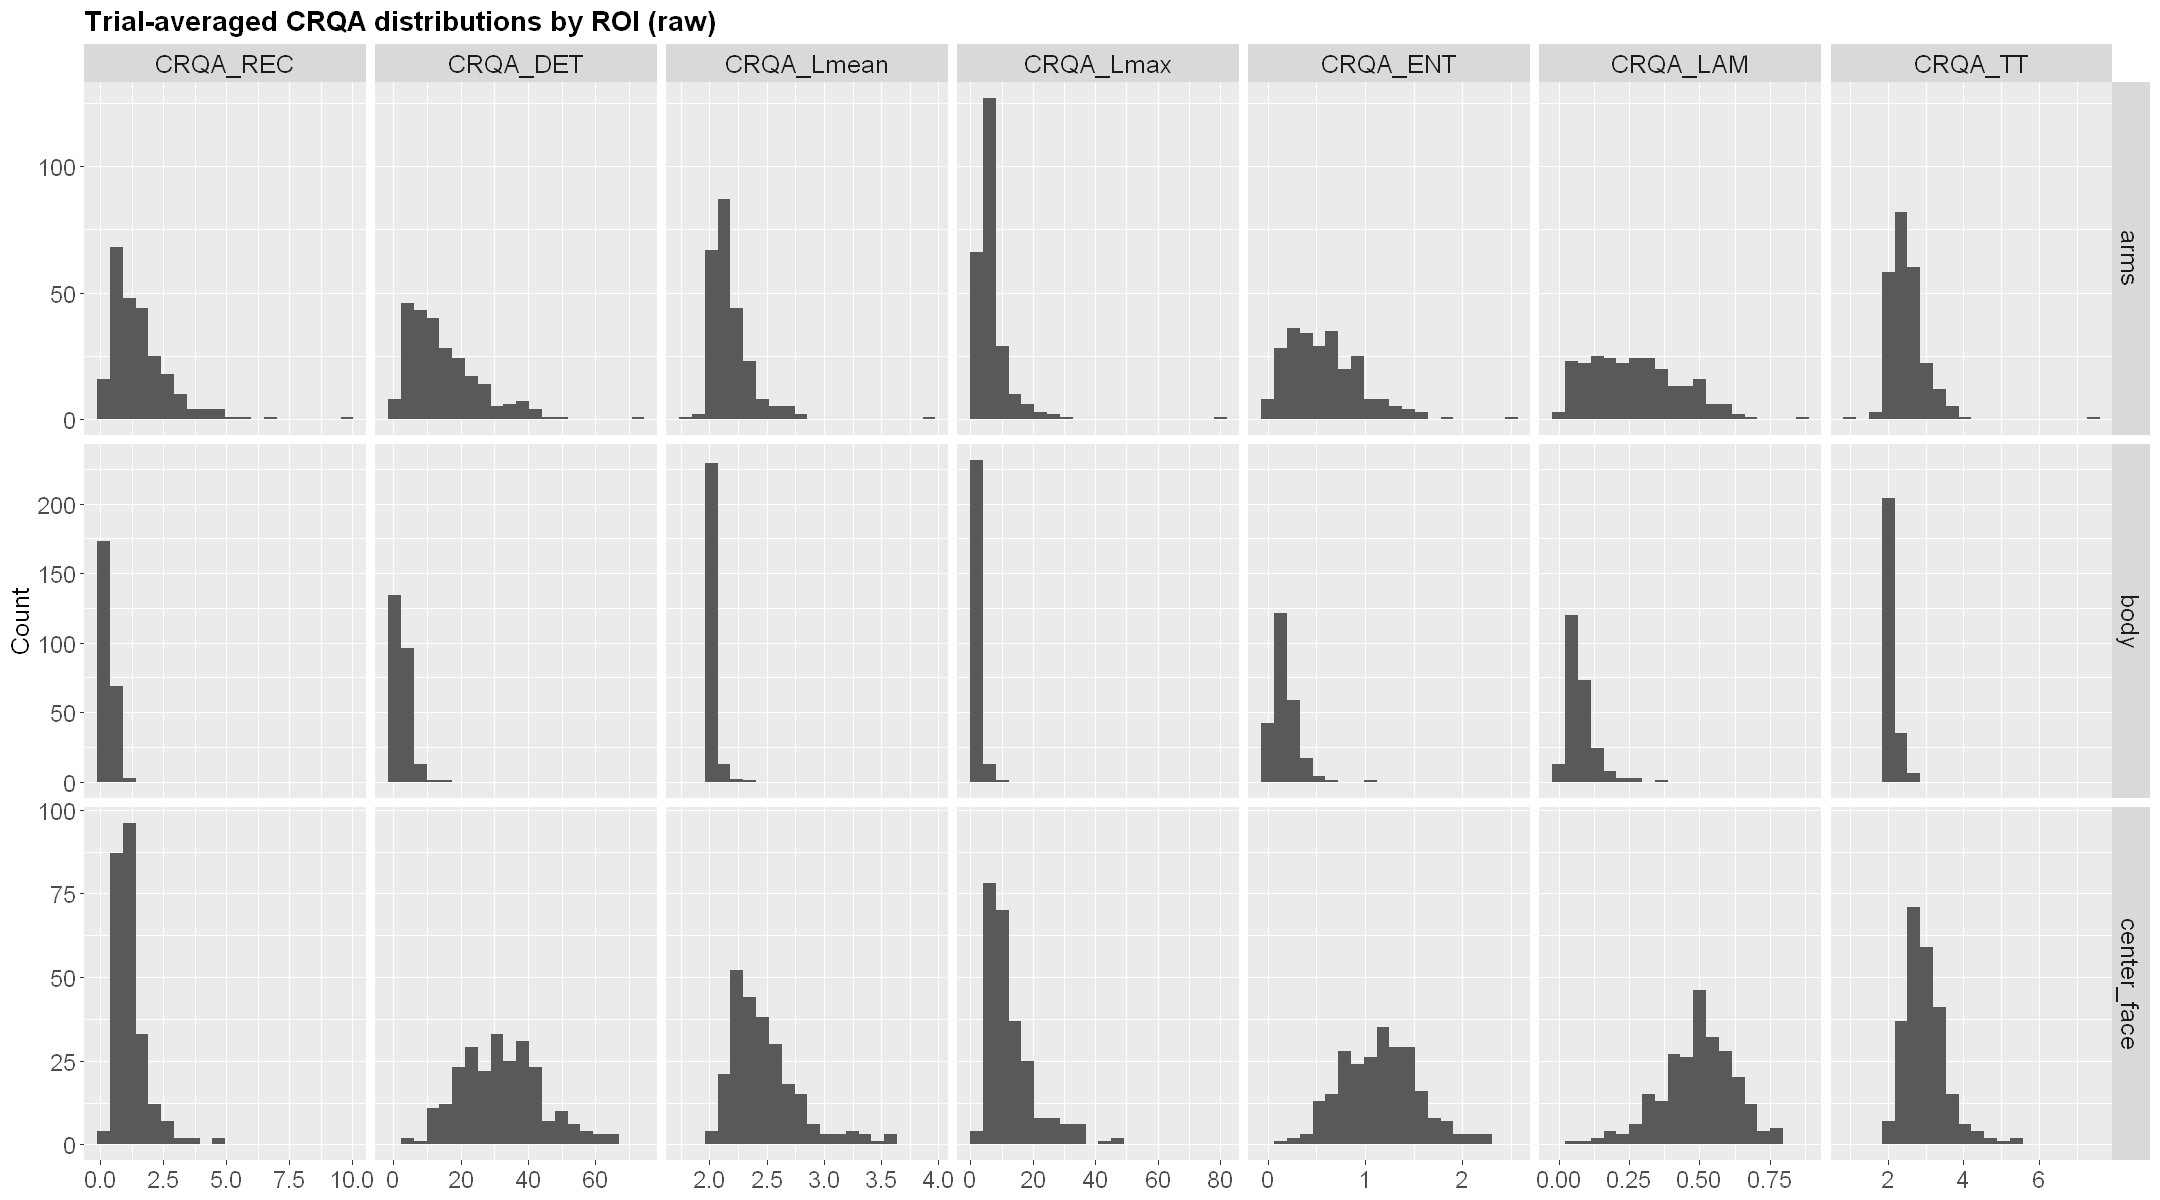

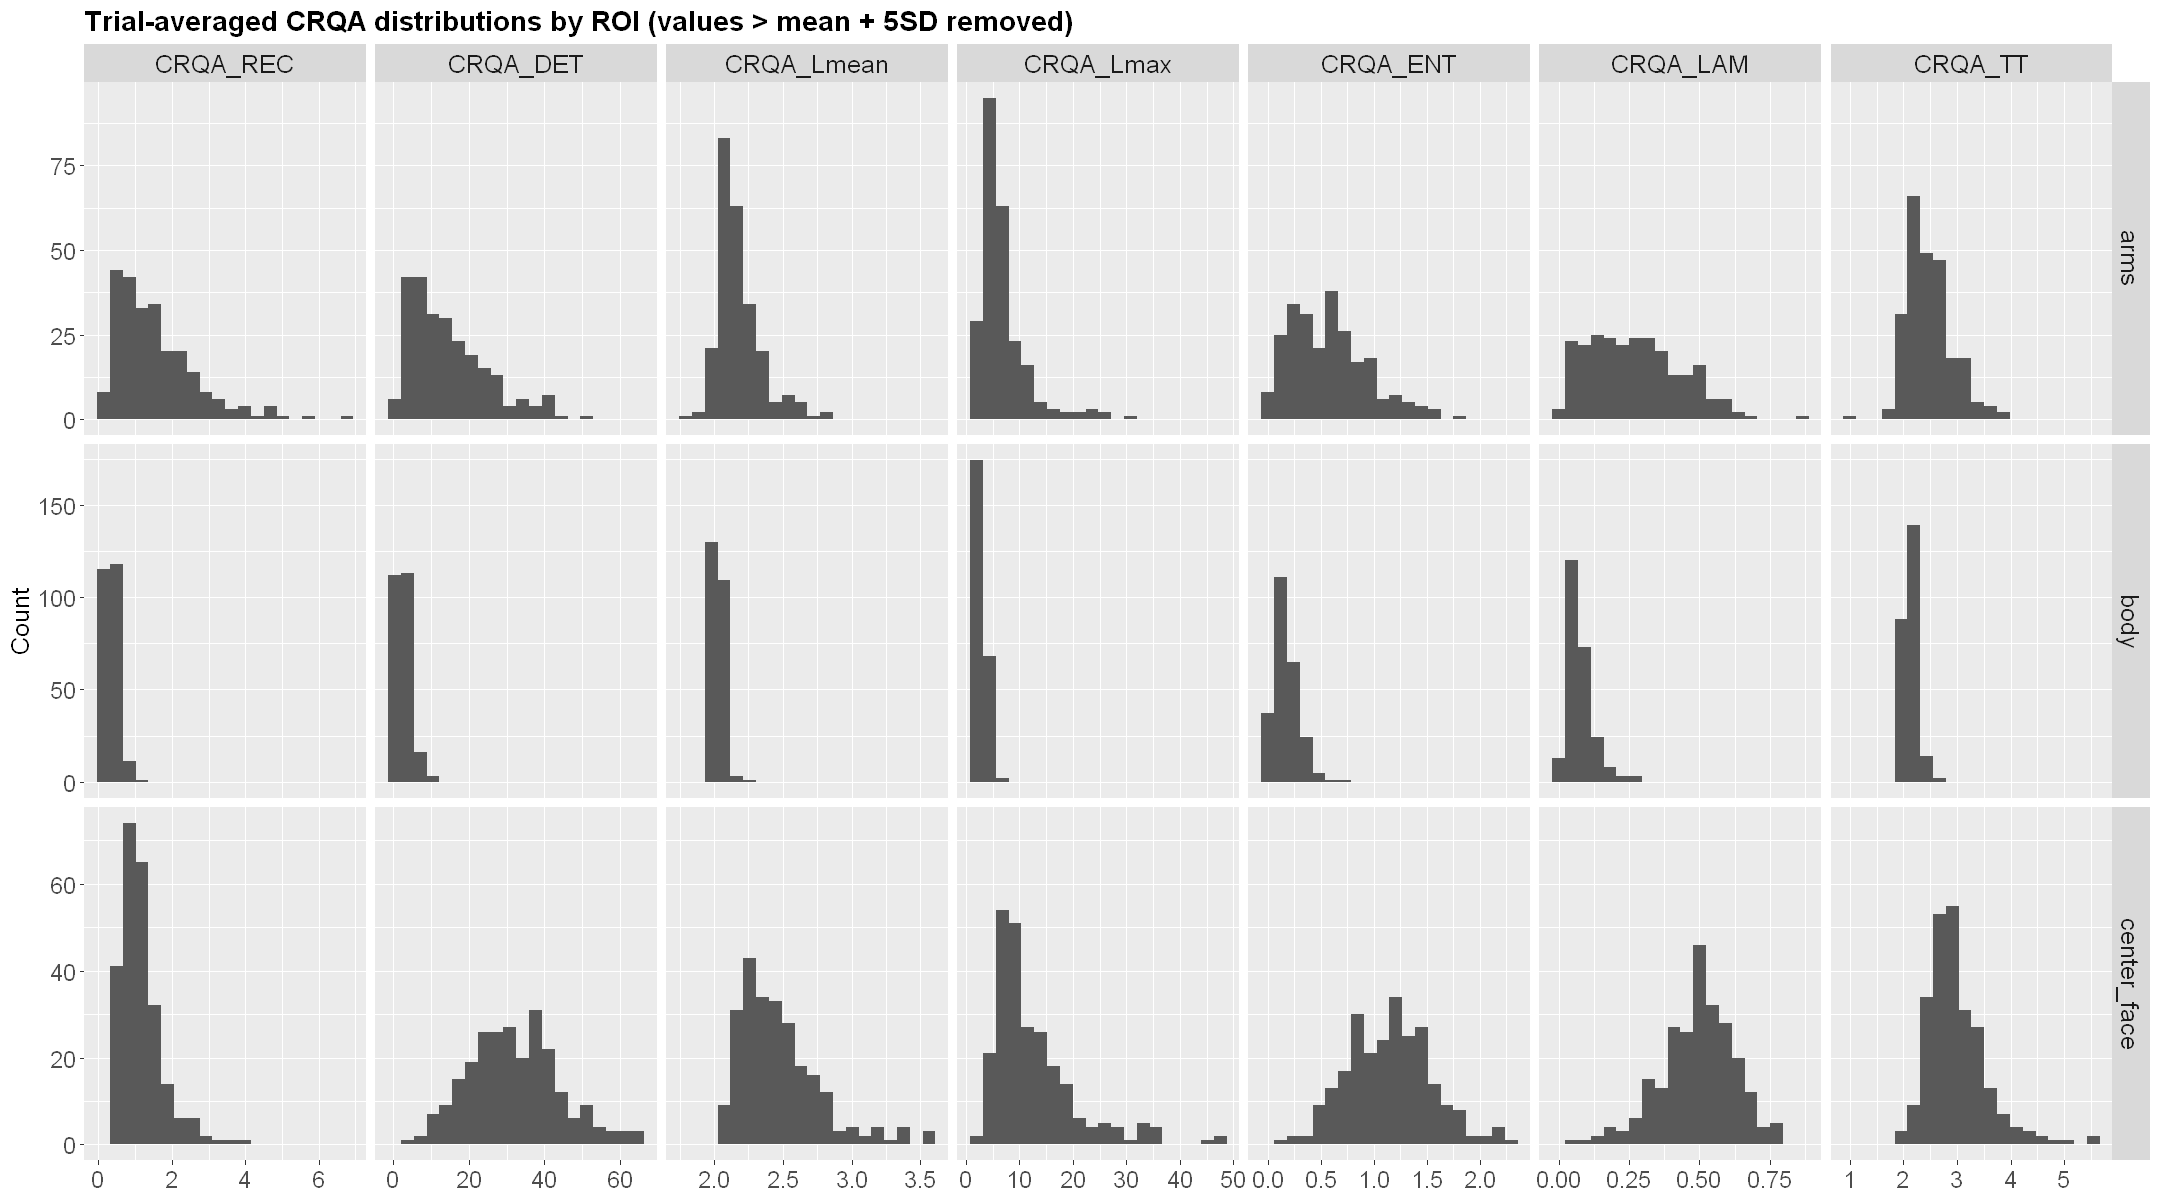

: 

In [ ]:
# Transforming DVs and inspecting distributions

# Desired order
metric_order <- c(
  "CRQA_REC",
  "CRQA_DET",
  "CRQA_Lmean",
  "CRQA_Lmax",
  "CRQA_ENT",
  "CRQA_LAM",
  "CRQA_TT"
)

# Pivot to long format for easy faceting
crqa_long <- crqa_av %>%
  pivot_longer(
    cols = starts_with("CRQA_"),
    names_to = "Metric",
    values_to = "Value"
  ) %>%
  mutate(
    Metric = factor(Metric, levels = metric_order)
  )

# Define plot theme
hist_theme <- theme(
  plot.title   = element_text(size = 17, face = "bold"),
  strip.text.x = element_text(size = 15),
  strip.text.y = element_text(size = 15),
  axis.text    = element_text(size = 14),
  axis.title   = element_text(size = 15)
)

# ------------------------------------------------------------
# Plot 1: raw histograms
# ------------------------------------------------------------
p_hist_raw <- ggplot(crqa_long, aes(x = Value)) +
  geom_histogram(bins = 20) +
  facet_grid(ROI ~ Metric, scales = "free") +
  labs(
    title = "Trial-averaged CRQA distributions by ROI (raw)",
    x = NULL,
    y = "Count"
  ) + hist_theme

options(repr.plot.width = 18, repr.plot.height = 10)
print(p_hist_raw)

# ------------------------------------------------------------
# Identify outliers: Value > mean + 5*SD, per Metric × ROI
# ------------------------------------------------------------
crqa_stats <- crqa_long %>%
  group_by(ROI, Metric) %>%
  summarise(
    mean_val = mean(Value, na.rm = TRUE),
    sd_val   = sd(Value, na.rm = TRUE),
    cutoff   = mean_val + 5 * sd_val,
    .groups = "drop"
  )

crqa_flagged <- crqa_long %>%
  left_join(crqa_stats, by = c("ROI", "Metric")) %>%
  mutate(
    is_outlier_5sd = is.finite(Value) & (Value > cutoff)
  )

# Print how many were removed per ROI × Metric
outlier_counts <- crqa_flagged %>%
  group_by(ROI, Metric) %>%
  summarise(
    n_total   = sum(is.finite(Value)),
    n_removed = sum(is_outlier_5sd, na.rm = TRUE),
    prop_removed = n_removed / n_total,
    cutoff = first(cutoff),
    .groups = "drop"
  ) %>%
  arrange(Metric, ROI)

print(outlier_counts)

# ------------------------------------------------------------
# Plot 2: histograms after removing +5SD outliers
# ------------------------------------------------------------
crqa_trim <- crqa_flagged %>%
  filter(!is_outlier_5sd) %>%
  select(ROI, Metric, Value)  # keep it tidy for plotting

p_hist_trim <- ggplot(crqa_trim, aes(x = Value)) +
  geom_histogram(bins = 20) +
  facet_grid(ROI ~ Metric, scales = "free") +
  labs(
    title = "Trial-averaged CRQA distributions by ROI (values > mean + 5SD removed)",
    x = NULL,
    y = "Count"
  ) + hist_theme

options(repr.plot.width = 18, repr.plot.height = 10)
print(p_hist_trim)


## Does this relationship change over time?

In [23]:
crqa_win <- crqa %>%
  group_by(Session, Trial) %>%
  mutate(
    Window_Prop = Window_Index / max(Window_Index, na.rm = TRUE),
    Window_Prop_c = Window_Prop - mean(Window_Prop, na.rm = TRUE)
  ) %>%
  ungroup()

str(crqa_win)

linear_win <- linear %>%
  group_by(Session, Trial) %>%
  mutate(
    Window_Prop = Window_Index / max(Window_Index, na.rm = TRUE),
    Window_Prop_c = Window_Prop - mean(Window_Prop, na.rm = TRUE)
  ) %>%
  ungroup()

str(linear_win)

tibble [5,190 × 20] (S3: tbl_df/tbl/data.frame)
 $ Session      : Factor w/ 45 levels "2","3","4","5",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Trial        : Factor w/ 6 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 2 ...
 $ Condition    : Factor w/ 4 levels "Cafe","Food",..: 3 3 3 3 3 3 3 3 3 2 ...
 $ Window_Size  : num [1:5190] 60 60 60 60 60 60 60 60 60 60 ...
 $ Window_Index : int [1:5190] 0 1 2 3 4 5 6 7 8 0 ...
 $ ROI          : Factor w/ 3 levels "arms","body",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Vector_Type  : chr [1:5190] "magnitude" "magnitude" "magnitude" "magnitude" ...
 $ Lag          : num [1:5190] 15 15 15 15 15 15 15 15 15 15 ...
 $ Embedding_Dim: num [1:5190] 4 4 4 4 4 4 4 4 4 4 ...
 $ Radius       : num [1:5190] 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 ...
 $ CRQA_REC     : num [1:5190] 1.52 1.04 1.11 1.01 1.69 ...
 $ CRQA_DET     : num [1:5190] 35 28.7 29.9 25.8 41.4 ...
 $ CRQA_Lmean   : num [1:5190] 2.42 2.36 2.29 2.25 2.73 ...
 $ CRQA_Lmax    : num [1:5190] 12 11 8 8 24 3